# Part 1 Choosing City for business

##### In this part we are using population data from [WorldPopulationReview](https://worldpopulationreview.com/world-cities/)

In [1]:
import pandas as pd
import numpy as np
import bs4
import requests
from bs4 import BeautifulSoup as soup
import requests # library to handle requests

In [4]:
r = requests.get('https://worldpopulationreview.com/world-cities/')
soup = bs4.BeautifulSoup(r.content, 'html.parser')
body = soup.body
t = body.tbody
if t:
    dfs = pd.read_html(str(body))
    df =dfs[0]
Cities=df
Cities.head()

,Rank,Name,Country,2020 Population,2019 Population,Change
0,1,Tokyo,Japan,37393129,37435191,-0.11%
1,2,Delhi,India,30290936,29399141,3.03%
2,3,Shanghai,China,27058479,26317104,2.82%
3,4,Sao Paulo,Brazil,22043028,21846507,0.90%
4,5,Mexico City,Mexico,21782378,21671908,0.51%


##### We need only US & Canada Cities

In [11]:
df2U=Cities[Cities['Country'].str.contains('United States')]
df2C=Cities[Cities['Country'].str.contains('Canada')]

#Join all cities in one dataframe
df2=pd.concat([df2U,df2C])
df2.rename(columns={"Name": "City"}, inplace=True)
df2.head()

,Rank,City,Country,2020 Population,2019 Population,Change
40,41,New York,United States,8323338,8361043,-0.45%
100,101,Los Angeles,United States,4015936,4003196,0.32%
170,171,Chicago,United States,2694236,2700115,-0.22%
199,200,Houston,United States,2340888,2333195,0.33%
281,282,Phoenix,United States,1703078,1681675,1.27%


In [15]:
df3=df2.sort_values(by='2020 Population', ascending=False)
df3.head()

,Rank,City,Country,2020 Population,2019 Population,Change
40,41,New York,United States,8323338,8361043,-0.45%
58,59,Toronto,Canada,6196731,6139404,0.93%
93,94,Montreal,Canada,4220566,4195523,0.60%
100,101,Los Angeles,United States,4015936,4003196,0.32%
170,171,Chicago,United States,2694236,2700115,-0.22%


In [16]:
df3['2020 Population']=df3['2020 Population'].astype('float')/1000000
df3['2020 Population']=round(df3['2020 Population'],3)
df3['2019 Population']=df3['2019 Population'].astype('float')/1000000
df3['2019 Population']=round(df3['2019 Population'],3)
df3=df3.rename(columns={"2020 Population": "M people in 2020"})
df3=df3.rename(columns={"2019 Population": "M people in 2019"})
df3=df3.rename(columns={"Change": "Change in %"})
df3["Change in %"]=df3["Change in %"].str.replace('%',"")
df3.head()

,Rank,City,Country,M people in 2020,M people in 2019,Change in %
40,41,New York,United States,8.323,8.361,-0.45
58,59,Toronto,Canada,6.197,6.139,0.93
93,94,Montreal,Canada,4.221,4.196,0.60
100,101,Los Angeles,United States,4.016,4.003,0.32
170,171,Chicago,United States,2.694,2.700,-0.22


In [18]:
df3a=df3.set_index('City')
df3a.head()

,Rank,Country,M people in 2020,M people in 2019,Change in %
City,,,,,
New York,41,United States,8.323,8.361,-0.45
Toronto,59,Canada,6.197,6.139,0.93
Montreal,94,Canada,4.221,4.196,0.60
Los Angeles,101,United States,4.016,4.003,0.32
Chicago,171,United States,2.694,2.700,-0.22


##### So let's visualize total population and annual change in % for each city!

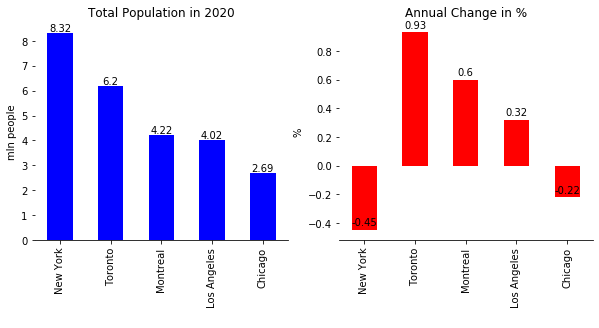

In [19]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fig = plt.figure() # create figure

ax0 = fig.add_subplot(1, 2, 1) # add subplot 1 (1 row, 5 columns, first plot)
ax1 = fig.add_subplot(1, 2, 2) # add subplot 2 (1 row, 5 columns, second plot). See tip below**

# Subplot 1: Box plot

#df3['2020_Population'].astype('int').plot(kind='bar', figsize=(8, 5), ax=ax0)

#plt.title('Total Population in 2020') # add a title to the histogram
#plt.ylabel('Number of Citizens') # add y-label
#plt.xlabel('City') # add x-label

df3a['M people in 2020'].astype('float').head(5).plot(kind='bar', color='blue', figsize=(10, 4), ax=ax0,) # add to subplot 1
ax0.set_title('Total Population in 2020')
ax0.set_xlabel(' ')
ax0.set_ylabel('mln people')
ax0.spines['right'].set_color('none')
ax0.spines['top'].set_color('none')
ax0.spines['left'].set_color('none')
for p in ax0.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax0.annotate('{:.3}'.format(height), (p.get_x()+.5*width, p.get_y() + height + 0.05), ha = 'center')

# Subplot 2: Line plot
df3a['Change in %'].astype('float').head(5).plot(kind='bar', color='red', figsize=(10, 4), ax=ax1) # add to subplot 2
ax1.set_title ('Annual Change in %')
ax1.set_ylabel('%')
ax1.set_xlabel(' ')
ax1.spines['right'].set_color('none')
ax1.spines['top'].set_color('none')
ax1.spines['left'].set_color('none')
for p in ax1.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax1.annotate('{:.3}'.format(height), (p.get_x()+.5*width, p.get_y() + height + 0.03), ha = 'center')
plt.show()

##### We see that the best city is Toronto! It is a large enough and has a positive dynamic!

# Part 2 Finding adresses of districts and neigborhoods of Toronto (ON)

##### In this part we are using adress data of districts and neigborhoods of Toronto from [Wikipedia](https://en.wikipedia.org/wiki/List_of_postal_codes_of_Canada:_M)

In [23]:
url = "https://en.wikipedia.org/wiki/List_of_postal_codes_of_Canada:_M"
df = pd.read_html(url, attrs={"class": "wikitable"})[0] # 0 is for the 1st table in this particular page
df

,Postal Code,Borough,Neighborhood
0,M1A,Not assigned,NaN
1,M2A,Not assigned,NaN
2,M3A,North York,Parkwoods
3,M4A,North York,Victoria Village
4,M5A,Downtown Toronto,"Regent Park, Harbourfront"
...,...,...,...
175,M5Z,Not assigned,NaN
176,M6Z,Not assigned,NaN
177,M7Z,Not assigned,NaN
178,M8Z,Etobicoke,"Mimico NW, The Queensway West, South of Bloor,..."


In [24]:
# Dropping the rows where Borough is 'Not assigned'
df1 = df[df.Borough != 'Not assigned'].reset_index(drop=True)
df1["Neighborhood"] = df1["Neighborhood"].str.replace(' /',",")
df1

,Postal Code,Borough,Neighborhood
0,M3A,North York,Parkwoods
1,M4A,North York,Victoria Village
2,M5A,Downtown Toronto,"Regent Park, Harbourfront"
3,M6A,North York,"Lawrence Manor, Lawrence Heights"
4,M7A,Downtown Toronto,"Queen's Park, Ontario Provincial Government"
...,...,...,...
98,M8X,Etobicoke,"The Kingsway, Montgomery Road, Old Mill North"
99,M4Y,Downtown Toronto,Church and Wellesley
100,M7Y,East Toronto,"Business reply mail Processing Centre, South C..."
101,M8Y,Etobicoke,"Old Mill South, King's Mill Park, Sunnylea, Hu..."


In [25]:
print(df1.shape)

(103, 3)


In [7]:
#df1.to_csv('Neigborhoods.csv') #backup Neigborhoods data for future work (if it is necessary)

### Finding geodata

##### Now we need to find geodata for all Toronto neiborhoods. We are using Geocoder here.

In [26]:
#!pip install geocoder
import geocoder # import geocoder

In [6]:
dfp=df1['Postal Code']
PC = pd.DataFrame(columns = ['Postal Code', 'Latitude', 'Longitude'])

In [9]:
for i in range(103):
    g = geocoder.arcgis('{}, Toronto, Ontario'.format(dfp[i]))
    lat_lng_coords = None
    lat_lng_coords = g.latlng
    latitude = lat_lng_coords[0]
    longitude = lat_lng_coords[1]
    PC.loc[i,'Postal Code'] = dfp[i]
    PC.loc[i,'Latitude'] = lat_lng_coords[0]
    PC.loc[i,'Longitude'] = lat_lng_coords[1]
PC.head()

,Postal Code,Latitude,Longitude
0,M3A,43.7529,-79.3356
1,M4A,43.7281,-79.3119
2,M5A,43.651,-79.353
3,M6A,43.7233,-79.4512
4,M7A,43.6618,-79.3894


In [11]:
PC.to_csv('Postal_Codes.csv') #backup geodata for future work (if it is necessary)

In [27]:
# Read geodata from backup file:
#PC=pd.read_csv('Postal_Codes.csv')
#PC=PC.drop(['Unnamed: 0'], axis=1)
#PC.head()

,Postal Code,Latitude,Longitude
0,M3A,43.752935,-79.335641
1,M4A,43.728102,-79.311890
2,M5A,43.650964,-79.353041
3,M6A,43.723265,-79.451211
4,M7A,43.661790,-79.389390


In [28]:
print(PC.shape)

(103, 3)


In [18]:
# Alternative method for testing geodata (from IBM Labs)
#Postal_Codes = pd.read_csv('http://cocl.us/Geospatial_data')
#Postal_Codes.head()

,Postal Code,Latitude,Longitude
0,M1B,43.806686,-79.194353
1,M1C,43.784535,-79.160497
2,M1E,43.763573,-79.188711
3,M1G,43.770992,-79.216917
4,M1H,43.773136,-79.239476


##### So let's join our datasets with adresses and geodata

In [30]:
df2=df1.join(PC.set_index('Postal Code'), on='Postal Code') #Postal_Codes for alternative method
df2

,Postal Code,Borough,Neighborhood,Latitude,Longitude
0,M3A,North York,Parkwoods,43.752935,-79.335641
1,M4A,North York,Victoria Village,43.728102,-79.311890
2,M5A,Downtown Toronto,"Regent Park, Harbourfront",43.650964,-79.353041
3,M6A,North York,"Lawrence Manor, Lawrence Heights",43.723265,-79.451211
4,M7A,Downtown Toronto,"Queen's Park, Ontario Provincial Government",43.661790,-79.389390
...,...,...,...,...,...
98,M8X,Etobicoke,"The Kingsway, Montgomery Road, Old Mill North",43.653340,-79.509766
99,M4Y,Downtown Toronto,Church and Wellesley,43.666659,-79.381472
100,M7Y,East Toronto,"Business reply mail Processing Centre, South C...",43.648700,-79.385450
101,M8Y,Etobicoke,"Old Mill South, King's Mill Park, Sunnylea, Hu...",43.632798,-79.493017


##### From [Wikipedia](https://en.wikipedia.org/wiki/List_of_neighbourhoods_in_Toronto) we know that Toronto has 4 districts of "Old Toronto" and 5 districts such as East York, Etobicoke, North York, Scarborough and York.
##### Let's find them in our dataset!

In [32]:
df2T=df2[:]
df2E=df2[:]
df2S=df2[:]
df2Y=df2[:]
df3T=df2T[df2T['Borough'].str.contains('Toronto')].reset_index(drop=True) #Downtown Toronto, East Toronto, West Toronto, Central Toronto
df3E=df2E[df2E['Borough'].str.contains('Etobicoke')].reset_index(drop=True) #Etobicoke
df3S=df2S[df2S['Borough'].str.contains('Scarborough')].reset_index(drop=True) #Scarborough
df3Y=df2Y[df2Y['Borough'].str.contains('York')].reset_index(drop=True) #East York, North York, York
#Join all districts in one dataframe
df3A=pd.concat([df3T,df3E,df3S,df3Y]).reset_index(drop=True)
df3A.head(10)

,Postal Code,Borough,Neighborhood,Latitude,Longitude
0,M5A,Downtown Toronto,"Regent Park, Harbourfront",43.650964,-79.353041
1,M7A,Downtown Toronto,"Queen's Park, Ontario Provincial Government",43.661790,-79.389390
2,M5B,Downtown Toronto,"Garden District, Ryerson",43.657491,-79.377529
3,M5C,Downtown Toronto,St. James Town,43.651734,-79.375554
4,M4E,East Toronto,The Beaches,43.678148,-79.295349
5,M5E,Downtown Toronto,Berczy Park,43.645196,-79.373855
6,M5G,Downtown Toronto,Central Bay Street,43.656072,-79.385653
7,M6G,Downtown Toronto,Christie,43.668602,-79.420387
8,M5H,Downtown Toronto,"Richmond, Adelaide, King",43.650542,-79.384116
9,M6H,West Toronto,"Dufferin, Dovercourt Village",43.664910,-79.438664


In [33]:
print('The dataframe has {} boroughs and {} neighborhoods.'.format(
        len(df3A['Borough'].unique()),
        df3A.shape[0]
    )
)

The dataframe has 9 boroughs and 102 neighborhoods.


##### Let's see them all on one map!

In [35]:
#!pip install geopy
from geopy.geocoders import Nominatim

In [36]:
#!pip install folium
import folium # map rendering library

In [37]:
address = 'Toronto, ON'

geolocator = Nominatim(user_agent="on_explorer")
location = geolocator.geocode(address)
latitude = location.latitude
longitude = location.longitude
print('The geograpical coordinate of Toronto are {}, {}.'.format(latitude, longitude))

The geograpical coordinate of Toronto are 43.6534817, -79.3839347.


In [38]:
# create map of New York using latitude and longitude values
map_toronto = folium.Map(location=[latitude, longitude], zoom_start=10)

# add markers to map
for lat, lng, borough, neighborhood in zip(df3A['Latitude'], df3A['Longitude'], df3A['Borough'], df3A['Neighborhood']):
    label = '{}, {}'.format(neighborhood, borough)
    label = folium.Popup(label, parse_html=True)
    folium.CircleMarker(
        [lat, lng],
        radius=5,
        popup=label,
        color='blue',
        fill=True,
        fill_color='#3186cc',
        fill_opacity=0.7,
        parse_html=False).add_to(map_toronto)  
    
map_toronto

##### Let's divide them by Borough

In [39]:
df3AG=df3A[:]
df3AGL=df3AG.groupby(['Borough']).count()
df3AGL.all

<bound method DataFrame.all of                   Postal Code  Neighborhood  Latitude  Longitude
Borough                                                         
Central Toronto             9             9         9          9
Downtown Toronto           19            19        19         19
East Toronto                5             5         5          5
East York                   5             5         5          5
Etobicoke                  12            12        12         12
North York                 24            24        24         24
Scarborough                17            17        17         17
West Toronto                6             6         6          6
York                        5             5         5          5>

In [40]:
df3AG2 = df3AG[:]
df3AG2['Cluster Labels'] = df3AG2['Borough']
df3AG2['Cluster Labels'] = df3AG2['Cluster Labels'].str.replace('Central Toronto',"0")
df3AG2['Cluster Labels'] = df3AG2['Cluster Labels'].str.replace('Downtown Toronto',"1")
df3AG2['Cluster Labels'] = df3AG2['Cluster Labels'].str.replace('East Toronto',"2")
df3AG2['Cluster Labels'] = df3AG2['Cluster Labels'].str.replace('West Toronto',"3")
df3AG2['Cluster Labels'] = df3AG2['Cluster Labels'].str.replace('Etobicoke',"4")
df3AG2['Cluster Labels'] = df3AG2['Cluster Labels'].str.replace('Scarborough',"5")
df3AG2['Cluster Labels'] = df3AG2['Cluster Labels'].str.replace('East York',"6")
df3AG2['Cluster Labels'] = df3AG2['Cluster Labels'].str.replace('North York',"7")
df3AG2['Cluster Labels'] = df3AG2['Cluster Labels'].str.replace('York',"8")
df3AG2['Cluster Labels'].astype('int32')

C:\Users\Dmitry\anaconda3\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\Users\Dmitry\anaconda3\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\Dmitry\anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

0      1
1      1
2      1
3      1
4      2
      ..
97     7
98     8
99     8
100    7
101    7
Name: Cluster Labels, Length: 102, dtype: int32

In [41]:
# Matplotlib and associated plotting modules
import matplotlib.cm as cm
import matplotlib.colors as colors

In [42]:
map_clusters = folium.Map(location=[latitude, longitude], zoom_start=10)
k=len(df3A['Borough'].unique())
# set color scheme for the clusters
x = np.arange(k)
ys = [i + x + (i*x)**2 for i in range(k)]
colors_array = cm.rainbow(np.linspace(0, 1, len(ys)))
rainbow = [colors.rgb2hex(i) for i in colors_array]


# add markers to the map
markers_colors = []
for i, lat, lon, neighbourhood, cluster in zip(range (102), df3AG2['Latitude'], df3AG2['Longitude'], df3AG2['Neighborhood'], df3AG2['Cluster Labels'].astype('int32')):
    label = folium.Popup(str(df3A.loc[i, 'Borough']), parse_html=True)
    folium.CircleMarker(
        [lat, lon],
        radius=5,
        popup=label,
        color=rainbow[cluster-1],
        fill=True,
        fill_color=rainbow[cluster-1],
        fill_opacity=0.7).add_to(map_clusters)
       
map_clusters

# Part 3 - Information about ethnic groups

##### From World Population Review we also know that Toronto is home to many ethnic neighborhoods such as Little India, Greektown, Corso Italia, Chinatown and others. We want to find if the needs for ethnic restaurants are sufficiently represented for each of these groups or is there a shortage of them.

From [Statistics Canada](https://www12.statcan.gc.ca/census-recensement/2016/dp-pd/prof/details/page.cfm?Lang=E&Geo1=CMACA&Code1=535&Geo2=PR&Code2=35&Data=Count&SearchText=Caledon%20East&SearchType=Begins&SearchPR=01&B1=All) site we have extracted iformation about languages spoken most often at home.

Data was extracted from csv file and prepared for analysis. Let's read it from file.

In [53]:
Lan=pd.read_excel('Language.xlsx') #was Extracted from Statistics Canada site
Lan

,Language,Total,Male,Female
0,Total - Language spoken most often at home for...,"5,883,670","2,858,785","3,024,880"
1,Single responses,"5,321,900","2,588,170","2,733,730"
2,Official languages,"3,866,565","1,899,565","1,966,995"
3,English,"3,836,765","1,885,800","1,950,970"
4,French,"29,795","13,770","16,030"
...,...,...,...,...
264,Multiple responses,"561,765","270,615","291,155"
265,English and French,"13,015","5,965","7,055"
266,English and non-official language,"535,630","258,900","276,730"
267,French and non-official language,"2,390","1,055","1,340"


##### Let's find out how many chinese, indian, greek, russian, itallian poeple using that data

In [64]:
LanGr=Lan[Lan['Language'].str.contains('Greek')].reset_index(drop=True)
LanRu=Lan[Lan['Language'].str.contains('Russian')].reset_index(drop=True)
LanIt=Lan[Lan['Language'].str.contains('Italian')].reset_index(drop=True)
LanHin=Lan[Lan['Language'].str.contains('Hin')].reset_index(drop=True)
LanChin=Lan[Lan['Language'].str.contains('Chinese languages')].reset_index(drop=True)
LanEtn=pd.concat([LanChin,LanRu,LanIt,LanHin,LanGr]).reset_index(drop=True)
LanEtn

,Language,Total,Male,Female
0,Chinese languages,"380,550","177,880","202,675"
1,"Chinese languages, n.i.e.",85,35,50
2,Russian,"53,675","24,950","28,720"
3,Italian,"51,815","22,250","29,560"
4,Hindi,"23,995","11,925","12,065"
5,Greek,"16,940","7,905","9,035"


In [65]:
LanEtn=LanEtn.drop([1, 1])
LanEtn

,Language,Total,Male,Female
0,Chinese languages,"380,550","177,880","202,675"
2,Russian,"53,675","24,950","28,720"
3,Italian,"51,815","22,250","29,560"
4,Hindi,"23,995","11,925","12,065"
5,Greek,"16,940","7,905","9,035"


In [66]:
LanEtn=LanEtn.drop(columns=['Male', 'Female'])
LanEtn["Total"]=LanEtn["Total"].str.replace(',',"")
LanEtn

,Language,Total
0,Chinese languages,380550
2,Russian,53675
3,Italian,51815
4,Hindi,23995
5,Greek,16940


##### Let's find if the needs for ethnic restaurants are sufficiently represented for each of these 5 groups or is there a shortage of them

# Part 4 - Forsquare data about venues

##### Lets's collect all data about venues of Toronto!

In [43]:
import json # library to handle JSON files
import requests # library to handle requests
from pandas.io.json import json_normalize # tranform JSON file into a pandas dataframe

In [44]:
CLIENT_ID = 'VIR3Y31UGLBKGGLEJRTSGUWGVDMGV1Y34QJ0SICHGLH5WQTX' # your Foursquare ID
CLIENT_SECRET = 'EARC4FCRIPZW0RS2WA5QBVJSV3WONMIDOOTXVWNKII0LJEKU' # your Foursquare Secret
VERSION = '20180605' # Foursquare API version

print('Your credentails:')
print('CLIENT_ID: ' + CLIENT_ID)
print('CLIENT_SECRET:' + CLIENT_SECRET)

Your credentails:
CLIENT_ID: VIR3Y31UGLBKGGLEJRTSGUWGVDMGV1Y34QJ0SICHGLH5WQTX
CLIENT_SECRET:EARC4FCRIPZW0RS2WA5QBVJSV3WONMIDOOTXVWNKII0LJEKU


In [45]:
df5=df3AG2.drop(['Cluster Labels'], axis=1)
df5.head()

,Postal Code,Borough,Neighborhood,Latitude,Longitude
0,M5A,Downtown Toronto,"Regent Park, Harbourfront",43.650964,-79.353041
1,M7A,Downtown Toronto,"Queen's Park, Ontario Provincial Government",43.661790,-79.389390
2,M5B,Downtown Toronto,"Garden District, Ryerson",43.657491,-79.377529
3,M5C,Downtown Toronto,St. James Town,43.651734,-79.375554
4,M4E,East Toronto,The Beaches,43.678148,-79.295349


In [33]:
def getNearbyVenues(names, latitudes, longitudes, radius=500):
    
    venues_list=[]
    for name, lat, lng in zip(names, latitudes, longitudes):
        print(name)
            
        # create the API request URL
        url = 'https://api.foursquare.com/v2/venues/explore?&client_id={}&client_secret={}&v={}&ll={},{}&radius={}&limit={}'.format(
            CLIENT_ID, 
            CLIENT_SECRET, 
            VERSION, 
            lat, 
            lng, 
            radius, 
            LIMIT)
            
        # make the GET request
        results = requests.get(url).json()["response"]['groups'][0]['items']
        
        # return only relevant information for each nearby venue
        venues_list.append([(
            name, 
            lat, 
            lng, 
            v['venue']['name'], 
            v['venue']['location']['lat'], 
            v['venue']['location']['lng'],  
            v['venue']['categories'][0]['name']) for v in results])

    nearby_venues = pd.DataFrame([item for venue_list in venues_list for item in venue_list])
    nearby_venues.columns = ['Neighborhood', 
                  'Neighborhood Latitude', 
                  'Neighborhood Longitude', 
                  'Venue', 
                  'Venue Latitude', 
                  'Venue Longitude', 
                  'Venue Category']
    
    return(nearby_venues)

In [34]:
LIMIT=100
toronto_venues = getNearbyVenues(names=df5['Neighborhood'],
                                   latitudes=df5['Latitude'],
                                   longitudes=df5['Longitude']
                                  )

Regent Park, Harbourfront
Queen's Park, Ontario Provincial Government
Garden District, Ryerson
St. James Town
The Beaches
Berczy Park
Central Bay Street
Christie
Richmond, Adelaide, King
Dufferin, Dovercourt Village
Harbourfront East, Union Station, Toronto Islands
Little Portugal, Trinity
The Danforth West, Riverdale
Toronto Dominion Centre, Design Exchange
Brockton, Parkdale Village, Exhibition Place
India Bazaar, The Beaches West
Commerce Court, Victoria Hotel
Studio District
Lawrence Park
Roselawn
Davisville North
Forest Hill North & West
High Park, The Junction South
North Toronto West
The Annex, North Midtown, Yorkville
Parkdale, Roncesvalles
Davisville
University of Toronto, Harbord
Runnymede, Swansea
Moore Park, Summerhill East
Kensington Market, Chinatown, Grange Park
Summerhill West, Rathnelly, South Hill, Forest Hill SE, Deer Park
CN Tower, King and Spadina, Railway Lands, Harbourfront West, Bathurst Quay, South Niagara, Island airport
Rosedale
Stn A PO Boxes
St. James Town,

In [38]:
toronto_venues.to_csv('Toronto_Venues.csv') #backup venues data for future work

In [46]:
#load venues data from file
#toronto_venues=pd.read_csv('Toronto_Venues.csv')
#toronto_venues=toronto_venues.drop(['Unnamed: 0'], axis=1)
#toronto_venues.head()

,Neighborhood,Neighborhood Latitude,Neighborhood Longitude,Venue,Venue Latitude,Venue Longitude,Venue Category
0,"Regent Park, Harbourfront",43.650964,-79.353041,Souk Tabule,43.653756,-79.354390,Mediterranean Restaurant
1,"Regent Park, Harbourfront",43.650964,-79.353041,Young Centre for the Performing Arts,43.650825,-79.357593,Performing Arts Venue
2,"Regent Park, Harbourfront",43.650964,-79.353041,SOMA chocolatemaker,43.650622,-79.358127,Chocolate Shop
3,"Regent Park, Harbourfront",43.650964,-79.353041,BATLgrounds,43.647088,-79.351306,Athletics & Sports
4,"Regent Park, Harbourfront",43.650964,-79.353041,Cluny Bistro & Boulangerie,43.650565,-79.357843,French Restaurant


In [47]:
toronto_venues.columns

Index(['Neighborhood', 'Neighborhood Latitude', 'Neighborhood Longitude',
       'Venue', 'Venue Latitude', 'Venue Longitude', 'Venue Category'],
      dtype='object')

In [48]:
print(toronto_venues.shape)
toronto_venues.head()

(2180, 7)


,Neighborhood,Neighborhood Latitude,Neighborhood Longitude,Venue,Venue Latitude,Venue Longitude,Venue Category
0,"Regent Park, Harbourfront",43.650964,-79.353041,Souk Tabule,43.653756,-79.354390,Mediterranean Restaurant
1,"Regent Park, Harbourfront",43.650964,-79.353041,Young Centre for the Performing Arts,43.650825,-79.357593,Performing Arts Venue
2,"Regent Park, Harbourfront",43.650964,-79.353041,SOMA chocolatemaker,43.650622,-79.358127,Chocolate Shop
3,"Regent Park, Harbourfront",43.650964,-79.353041,BATLgrounds,43.647088,-79.351306,Athletics & Sports
4,"Regent Park, Harbourfront",43.650964,-79.353041,Cluny Bistro & Boulangerie,43.650565,-79.357843,French Restaurant


##### Let's find information about Restaurants of Toronto

In [49]:
Rest=toronto_venues[toronto_venues['Venue Category'].str.contains('Restaurant')].reset_index(drop=True)
Rest

,Neighborhood,Neighborhood Latitude,Neighborhood Longitude,Venue,Venue Latitude,Venue Longitude,Venue Category
0,"Regent Park, Harbourfront",43.650964,-79.353041,Souk Tabule,43.653756,-79.354390,Mediterranean Restaurant
1,"Regent Park, Harbourfront",43.650964,-79.353041,Cluny Bistro & Boulangerie,43.650565,-79.357843,French Restaurant
2,"Regent Park, Harbourfront",43.650964,-79.353041,El Catrin,43.650601,-79.358920,Mexican Restaurant
3,"Regent Park, Harbourfront",43.650964,-79.353041,Sukhothai,43.653701,-79.354447,Thai Restaurant
4,"Regent Park, Harbourfront",43.650964,-79.353041,Pure Spirits Oyster House & Grill,43.650409,-79.358648,Seafood Restaurant
...,...,...,...,...,...,...,...
509,Downsview,43.755819,-79.519973,Pho Com Viet Nam,43.756631,-79.518336,Vietnamese Restaurant
510,Downsview,43.755819,-79.519973,KFC,43.756600,-79.518100,Fast Food Restaurant
511,Downsview,43.755819,-79.519973,Living Well,43.756461,-79.515989,Caribbean Restaurant
512,Downsview,43.755819,-79.519973,Pita Land,43.757520,-79.514628,Falafel Restaurant


In [50]:
Rest.groupby('Neighborhood').count()

,Neighborhood Latitude,Neighborhood Longitude,Venue,Venue Latitude,Venue Longitude,Venue Category
Neighborhood,,,,,,
Agincourt,1,1,1,1,1,1
"Bathurst Manor, Wilson Heights, Downsview North",4,4,4,4,4,4
"Bedford Park, Lawrence Manor East",9,9,9,9,9,9
Berczy Park,13,13,13,13,13,13
"Birch Cliff, Cliffside West",1,1,1,1,1,1
"Brockton, Parkdale Village, Exhibition Place",10,10,10,10,10,10
Business reply mail Processing Centre,29,29,29,29,29,29
"CN Tower, King and Spadina, Railway Lands, Harbourfront West, Bathurst Quay, South Niagara, Island airport",20,20,20,20,20,20
Caledonia-Fairbanks,1,1,1,1,1,1


In [40]:
Rest.groupby('Venue Category').count().sort_values(by='Neighborhood', ascending=False)

,Neighborhood,Neighborhood Latitude,Neighborhood Longitude,Venue,Venue Latitude,Venue Longitude
Venue Category,,,,,,
Restaurant,74,74,74,74,74,74
Japanese Restaurant,44,44,44,44,44,44
Italian Restaurant,40,40,40,40,40,40
Sushi Restaurant,34,34,34,34,34,34
American Restaurant,29,29,29,29,29,29
Fast Food Restaurant,29,29,29,29,29,29
Thai Restaurant,26,26,26,26,26,26
Seafood Restaurant,24,24,24,24,24,24
Asian Restaurant,18,18,18,18,18,18


##### For chinese group we see chinese (12) and asian (18) restaurants. But there is no russian restaurants at all! So for russian group we took Eastern European restaurant (4).

In [69]:
EtnRest=LanEtn[:]

In [70]:
EtnRest['Restaurant Count']=[12+18,4,40,13,10] #taken from table above
EtnRest

C:\Users\Dmitry\anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,Language,Total,Restaurant Count
0,Chinese languages,380550,30
2,Russian,53675,4
3,Italian,51815,40
4,Hindi,23995,13
5,Greek,16940,10


In [71]:
EtnRest['Proportion']=EtnRest['Restaurant Count']/EtnRest['Total'].astype('int')*10000
EtnRest

C:\Users\Dmitry\anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,Language,Total,Restaurant Count,Proportion
0,Chinese languages,380550,30,0.788333
2,Russian,53675,4,0.745226
3,Italian,51815,40,7.719772
4,Hindi,23995,13,5.417795
5,Greek,16940,10,5.903188


In [73]:
EtnRest["Language"]=EtnRest["Language"].str.replace(' languages',"")
EtnRest

C:\Users\Dmitry\anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,Language,Total,Restaurant Count,Proportion
0,Chinese,380550,30,0.788333
2,Russian,53675,4,0.745226
3,Italian,51815,40,7.719772
4,Hindi,23995,13,5.417795
5,Greek,16940,10,5.903188


In [75]:
EtnRestL=EtnRest.set_index('Language')

##### Let's visualize it!

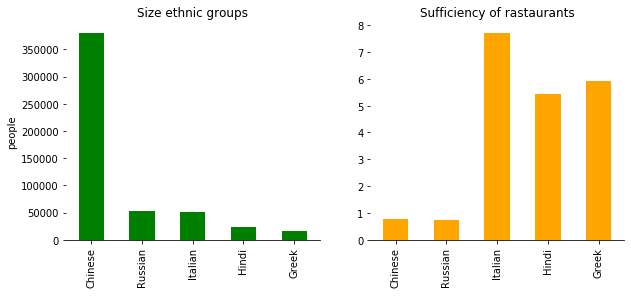

In [106]:
fig = plt.figure() # create figure

ax0 = fig.add_subplot(1, 2, 1) # add subplot 1 (1 row, 5 columns, first plot)
ax1 = fig.add_subplot(1, 2, 2) # add subplot 2 (1 row, 5 columns, second plot). See tip below**

# Subplot 1: Box plot

#df3['2020_Population'].astype('int').plot(kind='bar', figsize=(8, 5), ax=ax0)

#plt.title('Total Population in 2020') # add a title to the histogram
#plt.ylabel('Number of Citizens') # add y-label
#plt.xlabel('City') # add x-label

EtnRestL['Total'].astype('int').head(5).plot(kind='bar', color='green', figsize=(10, 4), ax=ax0,) # add to subplot 1
ax0.set_title('Size ethnic groups')
ax0.set_xlabel(' ')
ax0.set_ylabel('people')
ax0.spines['right'].set_color('none')
ax0.spines['top'].set_color('none')
ax0.spines['left'].set_color('none')

# Subplot 2: Line plot
EtnRestL['Proportion'].astype('float').head(5).plot(kind='bar', color='orange', figsize=(10, 4), ax=ax1) # add to subplot 2
ax1.set_title ('Sufficiency of rastaurants')
ax1.set_ylabel('')
ax1.set_xlabel(' ')
ax1.spines['right'].set_color('none')
ax1.spines['top'].set_color('none')
ax1.spines['left'].set_color('none')

plt.show()

#### At least two conclusions can be drawn from this data:
##### - There is still a shortage of chinese restaurant. But you can still visit Korean (5) and Thai (26) restaurants
##### - There is a clear lack of options for representatives of the Russian group. We didn't find a single Russian restaurant, and we took the closest ones - Eastern European restaurants in the statistics.

# Part 5 Finding the best neighborhoods to start a restaurant business

Now we want to find the most successful places to start a restaurant business. We have selected the most suitable venues categories in our opinion next to which our restaurant could be located.

In [80]:
College=toronto_venues[toronto_venues['Venue Category'].str.contains('College')].reset_index(drop=True)
Park=toronto_venues[toronto_venues['Venue Category'].str.contains('Park')].reset_index(drop=True)
Garden=toronto_venues[toronto_venues['Venue Category'].str.contains('Garden')].reset_index(drop=True)
Hotel=toronto_venues[toronto_venues['Venue Category'].str.contains('Hotel')].reset_index(drop=True)
Museum=toronto_venues[toronto_venues['Venue Category'].str.contains('Museum')].reset_index(drop=True)
Theater=toronto_venues[toronto_venues['Venue Category'].str.contains('Theater')].reset_index(drop=True)
Concert=toronto_venues[toronto_venues['Venue Category'].str.contains('Concert')].reset_index(drop=True)

In [81]:
Places=pd.concat([Theater,Museum,Hotel,Garden,Park,College,Concert]).reset_index(drop=True)
Places

,Neighborhood,Neighborhood Latitude,Neighborhood Longitude,Venue,Venue Latitude,Venue Longitude,Venue Category
0,"Regent Park, Harbourfront",43.650964,-79.353041,Soulpepper Theatre,43.650780,-79.357615,Theater
1,"Queen's Park, Ontario Provincial Government",43.661790,-79.389390,Hart House Theatre,43.663571,-79.394616,Theater
2,"Garden District, Ryerson",43.657491,-79.377529,Ed Mirvish Theatre,43.655102,-79.379768,Theater
3,"Garden District, Ryerson",43.657491,-79.377529,Elgin And Winter Garden Theatres,43.653394,-79.378507,Theater
4,"Garden District, Ryerson",43.657491,-79.377529,VISA Screening Room #TIFF,43.653415,-79.378459,Movie Theater
...,...,...,...,...,...,...,...
168,Stn A PO Boxes,43.648700,-79.385450,Roy Thomson Hall,43.646589,-79.385979,Concert Hall
169,"First Canadian Place, Underground city",43.648269,-79.381884,Roy Thomson Hall,43.646589,-79.385979,Concert Hall
170,"First Canadian Place, Underground city",43.648269,-79.381884,Four Seasons Centre for the Performing Arts,43.650592,-79.385806,Concert Hall
171,Business reply mail Processing Centre,43.648700,-79.385450,Four Seasons Centre for the Performing Arts,43.650592,-79.385806,Concert Hall


In [82]:
Places.groupby('Neighborhood').count()

,Neighborhood Latitude,Neighborhood Longitude,Venue,Venue Latitude,Venue Longitude,Venue Category
Neighborhood,,,,,,
"Bathurst Manor, Wilson Heights, Downsview North",1,1,1,1,1,1
Berczy Park,5,5,5,5,5,5
"Birch Cliff, Cliffside West",1,1,1,1,1,1
"Brockton, Parkdale Village, Exhibition Place",1,1,1,1,1,1
Business reply mail Processing Centre,13,13,13,13,13,13
"CN Tower, King and Spadina, Railway Lands, Harbourfront West, Bathurst Quay, South Niagara, Island airport",7,7,7,7,7,7
Caledonia-Fairbanks,2,2,2,2,2,2
Central Bay Street,4,4,4,4,4,4
Christie,1,1,1,1,1,1


## Analyze Each Neighborhood

In [83]:
# one hot encoding
toronto_onehot = pd.get_dummies(Places[['Venue Category']], prefix="", prefix_sep="")

# add neighborhood column back to dataframe
toronto_onehot['Neighborhood'] = Places['Neighborhood'] 

# move neighborhood column to the first column
fixed_columns = [toronto_onehot.columns[-1]] + list(toronto_onehot.columns[:-1])
toronto_onehot = toronto_onehot[fixed_columns]

toronto_onehot.head()

,Neighborhood,Art Museum,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall,Garden,...,History Museum,Hotel,Hotel Bar,Indie Movie Theater,Movie Theater,Museum,Park,Sculpture Garden,Theater,Theme Park
0,"Regent Park, Harbourfront",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,"Queen's Park, Ontario Provincial Government",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,"Garden District, Ryerson",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,"Garden District, Ryerson",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,"Garden District, Ryerson",0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [87]:
Places.groupby('Neighborhood').count()

,Neighborhood Latitude,Neighborhood Longitude,Venue,Venue Latitude,Venue Longitude,Venue Category
Neighborhood,,,,,,
"Bathurst Manor, Wilson Heights, Downsview North",1,1,1,1,1,1
Berczy Park,5,5,5,5,5,5
"Birch Cliff, Cliffside West",1,1,1,1,1,1
"Brockton, Parkdale Village, Exhibition Place",1,1,1,1,1,1
Business reply mail Processing Centre,13,13,13,13,13,13
"CN Tower, King and Spadina, Railway Lands, Harbourfront West, Bathurst Quay, South Niagara, Island airport",7,7,7,7,7,7
Caledonia-Fairbanks,2,2,2,2,2,2
Central Bay Street,4,4,4,4,4,4
Christie,1,1,1,1,1,1


In [88]:
print('There are {} uniques categories.'.format(len(Places['Venue Category'].unique())))

There are 20 uniques categories.


#### Next, let's group rows by neighborhood and by taking the mean of the frequency of occurrence of each category

In [89]:
toronto_grouped = toronto_onehot.groupby('Neighborhood').mean().reset_index()
toronto_grouped

,Neighborhood,Art Museum,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall,Garden,...,History Museum,Hotel,Hotel Bar,Indie Movie Theater,Movie Theater,Museum,Park,Sculpture Garden,Theater,Theme Park
0,"Bathurst Manor, Wilson Heights, Downsview North",0.000000,0.000000,0.0,0.0,0.000000,0.000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.0,0.000000,0.000000
1,Berczy Park,0.000000,0.000000,0.0,0.0,0.000000,0.000,0.0,0.200000,0.000000,...,0.0,0.400000,0.000000,0.0,0.000000,0.200000,0.200000,0.0,0.000000,0.000000
2,"Birch Cliff, Cliffside West",0.000000,0.000000,0.0,0.0,0.000000,0.000,1.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
3,"Brockton, Parkdale Village, Exhibition Place",0.000000,0.000000,0.0,0.0,0.000000,0.000,0.0,0.000000,0.000000,...,0.0,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
4,Business reply mail Processing Centre,0.000000,0.000000,0.0,0.0,0.000000,0.000,0.0,0.153846,0.076923,...,0.0,0.384615,0.000000,0.0,0.153846,0.000000,0.076923,0.0,0.153846,0.000000
5,"CN Tower, King and Spadina, Railway Lands, Har...",0.000000,0.000000,0.0,0.0,0.142857,0.000,0.0,0.000000,0.142857,...,0.0,0.142857,0.142857,0.0,0.000000,0.000000,0.428571,0.0,0.000000,0.000000
6,Caledonia-Fairbanks,0.000000,0.000000,0.0,0.0,0.000000,0.000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.0,0.000000,0.000000
7,Central Bay Street,0.250000,0.000000,0.0,0.0,0.000000,0.000,0.0,0.000000,0.000000,...,0.0,0.250000,0.000000,0.0,0.000000,0.000000,0.250000,0.0,0.250000,0.000000
8,Christie,0.000000,0.000000,0.0,0.0,0.000000,0.000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.0,0.000000,0.000000
9,Church and Wellesley,0.000000,0.000000,0.0,0.0,0.000000,0.000,0.0,0.000000,0.000000,...,0.0,0.400000,0.000000,0.0,0.000000,0.000000,0.200000,0.2,0.200000,0.000000


In [90]:
toronto_grouped.shape

(59, 21)

In [91]:
num_top_venues = 5

for hood in toronto_grouped['Neighborhood']:
    print("----"+hood+"----")
    temp = toronto_grouped[toronto_grouped['Neighborhood'] == hood].T.reset_index()
    temp.columns = ['venue','freq']
    temp = temp.iloc[1:]
    temp['freq'] = temp['freq'].astype(float)
    temp = temp.round({'freq': 2})
    print(temp.sort_values('freq', ascending=False).reset_index(drop=True).head(num_top_venues))
    print('\n')

----Bathurst Manor, Wilson Heights, Downsview North----
                   venue  freq
0                   Park   1.0
1             Art Museum   0.0
2  College Arts Building   0.0
3                Theater   0.0
4       Sculpture Garden   0.0


----Berczy Park----
          venue  freq
0         Hotel   0.4
1          Park   0.2
2        Museum   0.2
3  Concert Hall   0.2
4    Art Museum   0.0


----Birch Cliff, Cliffside West----
              venue  freq
0   College Stadium   1.0
1        Art Museum   0.0
2             Hotel   0.0
3           Theater   0.0
4  Sculpture Garden   0.0


----Brockton, Parkdale Village, Exhibition Place----
                   venue  freq
0                  Hotel   1.0
1             Art Museum   0.0
2  College Arts Building   0.0
3                Theater   0.0
4       Sculpture Garden   0.0


----Business reply mail Processing Centre----
           venue  freq
0          Hotel  0.38
1        Theater  0.15
2  Movie Theater  0.15
3   Concert Hall  0.15
4     

#### Let's put that into a *pandas* dataframe

In [92]:
def return_most_common_venues(row, num_top_venues):
    row_categories = row.iloc[1:]
    row_categories_sorted = row_categories.sort_values(ascending=False)
    
    return row_categories_sorted.index.values[0:num_top_venues]

In [93]:
num_top_venues = 10

indicators = ['st', 'nd', 'rd']

# create columns according to number of top venues
columns = ['Neighborhood']
for ind in np.arange(num_top_venues):
    try:
        columns.append('{}{} Most Common Venue'.format(ind+1, indicators[ind]))
    except:
        columns.append('{}th Most Common Venue'.format(ind+1))

# create a new dataframe
neighborhoods_venues_sorted = pd.DataFrame(columns=columns)
neighborhoods_venues_sorted['Neighborhood'] = toronto_grouped['Neighborhood']

for ind in np.arange(toronto_grouped.shape[0]):
    neighborhoods_venues_sorted.iloc[ind, 1:] = return_most_common_venues(toronto_grouped.iloc[ind, :], num_top_venues)

neighborhoods_venues_sorted.head()

,Neighborhood,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,"Bathurst Manor, Wilson Heights, Downsview North",Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
1,Berczy Park,Hotel,Concert Hall,Park,Museum,Theme Park,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center
2,"Birch Cliff, Cliffside West",College Stadium,Theme Park,Theater,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,Concert Hall,Garden
3,"Brockton, Parkdale Village, Exhibition Place",Hotel,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
4,Business reply mail Processing Centre,Hotel,Movie Theater,Theater,Concert Hall,Park,Garden,Theme Park,College Stadium,College Arts Building,College Auditorium


## Cluster Neighborhoods

In [94]:
# Matplotlib and associated plotting modules
import matplotlib.cm as cm
import matplotlib.colors as colors

# import k-means from clustering stage
from sklearn.cluster import KMeans

In [95]:
# set number of clusters
kclusters = 4

toronto_grouped_clustering = toronto_grouped.drop('Neighborhood', 1)

# run k-means clustering
kmeans = KMeans(n_clusters=kclusters, random_state=0).fit(toronto_grouped_clustering)

# check cluster labels generated for each row in the dataframe
kmeans.labels_[0:10] 

array([1, 2, 3, 2, 2, 3, 1, 3, 1, 2])

In [96]:
# add clustering labels
neighborhoods_venues_sorted.insert(0, 'Cluster Labels', kmeans.labels_)

toronto_merged = df5

# merge toronto_grouped with toronto_data to add latitude/longitude for each neighborhood
toronto_merged = toronto_merged.join(neighborhoods_venues_sorted.set_index('Neighborhood'), on='Neighborhood')

toronto_merged.head() # check the last columns!

,Postal Code,Borough,Neighborhood,Latitude,Longitude,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,M5A,Downtown Toronto,"Regent Park, Harbourfront",43.650964,-79.353041,0.0,Theater,Theme Park,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall,Garden
1,M7A,Downtown Toronto,"Queen's Park, Ontario Provincial Government",43.661790,-79.389390,3.0,College Cafeteria,Park,College Auditorium,Theater,Theme Park,Garden,College Arts Building,College Gym,College Rec Center,College Stadium
2,M5B,Downtown Toronto,"Garden District, Ryerson",43.657491,-79.377529,2.0,Hotel,Movie Theater,Theater,College Rec Center,Theme Park,Concert Hall,College Arts Building,College Auditorium,College Cafeteria,College Gym
3,M5C,Downtown Toronto,St. James Town,43.651734,-79.375554,0.0,Theater,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium
4,M4E,East Toronto,The Beaches,43.678148,-79.295349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
toronto_merged=toronto_merged.dropna(subset=['Cluster Labels'])

In [98]:
# create map
map_clusters = folium.Map(location=[latitude, longitude], zoom_start=11)

# set color scheme for the clusters
x = np.arange(kclusters)
ys = [i + x + (i*x)**2 for i in range(kclusters)]
colors_array = cm.rainbow(np.linspace(0, 1, len(ys)))
rainbow = [colors.rgb2hex(i) for i in colors_array]

# add markers to the map
markers_colors = []
for lat, lon, poi, cluster in zip(toronto_merged['Latitude'], toronto_merged['Longitude'], toronto_merged['Neighborhood'], toronto_merged['Cluster Labels'].astype('int')):
    label = folium.Popup(str(poi) + ' Cluster ' + str(cluster+1), parse_html=True)
    folium.CircleMarker(
        [lat, lon],
        radius=5,
        popup=label,
        color=rainbow[cluster-1],
        fill=True,
        fill_color=rainbow[cluster-1],
        fill_opacity=0.7).add_to(map_clusters)
       
map_clusters

## Examine Clusters

#### Cluster 1

In [99]:
toronto_merged.loc[toronto_merged['Cluster Labels'] == 0, toronto_merged.columns[[1] + list(range(5, toronto_merged.shape[1]))]].head()

,Borough,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,Downtown Toronto,0.0,Theater,Theme Park,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall,Garden
3,Downtown Toronto,0.0,Theater,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium
11,West Toronto,0.0,Park,Theater,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium


#### Cluster 2

In [104]:
toronto_merged.loc[toronto_merged['Cluster Labels'] == 1, toronto_merged.columns[[1] + list(range(5, toronto_merged.shape[1]))]].head(10)

,Borough,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
7,Downtown Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
9,West Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
12,East Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
20,Central Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
22,West Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
26,Central Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
29,Central Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
31,Central Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
33,Downtown Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
35,Downtown Toronto,1.0,Park,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall


#### Cluster 3

In [101]:
toronto_merged.loc[toronto_merged['Cluster Labels'] == 2, toronto_merged.columns[[1] + list(range(5, toronto_merged.shape[1]))]].head()

,Borough,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
2,Downtown Toronto,2.0,Hotel,Movie Theater,Theater,College Rec Center,Theme Park,Concert Hall,College Arts Building,College Auditorium,College Cafeteria,College Gym
5,Downtown Toronto,2.0,Hotel,Concert Hall,Park,Museum,Theme Park,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center
8,Downtown Toronto,2.0,Hotel,Concert Hall,Art Museum,Theater,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center
13,Downtown Toronto,2.0,Hotel,Concert Hall,Museum,Theater,Theme Park,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center
14,West Toronto,2.0,Hotel,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall


#### Cluster 4

In [102]:
toronto_merged.loc[toronto_merged['Cluster Labels'] == 3, toronto_merged.columns[[1] + list(range(5, toronto_merged.shape[1]))]].head()

,Borough,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
1,Downtown Toronto,3.0,College Cafeteria,Park,College Auditorium,Theater,Theme Park,Garden,College Arts Building,College Gym,College Rec Center,College Stadium
6,Downtown Toronto,3.0,Art Museum,Park,Hotel,Theater,Concert Hall,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center
10,Downtown Toronto,3.0,Theme Park,Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall
15,East Toronto,3.0,Park,Movie Theater,Theme Park,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium
24,Central Toronto,3.0,Garden Center,History Museum,Garden,College Arts Building,College Auditorium,College Cafeteria,College Gym,College Rec Center,College Stadium,Concert Hall


As we can see, clusters 1 and 3 are mostly concentrated in the Central part of Toronto, so in our opinion they are the most successful options for placing a restaurant in terms of the largest concentration of people. 
The most frequent venue categories in cluster 1 are parks, theaters, gardens and college buildings. Therefore, we believe that we should focus on young people and students in this cluster. In addition, frequent visitors to these places are both permanent residents and tourists.
The most frequent venue categories in cluster 3 are hotels, concert halls, museums. Therefore, we believe that we should focus on tourists and and visitors from other cities in this cluster.